In [1]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer

In [8]:
df1_train  = pd.read_csv('../data/phase_1/Training_dataset_1.csv', na_values=['-999.25']) 
df2_train  = pd.read_csv('../data/phase_1/Training_dataset_2.csv', na_values=['-999.25'])  
df3_train  = pd.read_csv('../data/phase_1/Training_dataset_3.csv', na_values=['-999.25'])  

df1_test   = pd.read_csv('../data/phase_1/Test_dataset_1.csv')
df2_test   = pd.read_csv('../data/phase_1/Test_dataset_2.csv')
df3_test   = pd.read_csv('../data/phase_1/Test_dataset_3.csv')

In [20]:
import missingno as msno
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt

def debug_missing_data(df, threshold=20):
    """
    Debug missing data analysis for numerical columns with detailed shape information at each step.
    
    Parameters:
    df (pandas.DataFrame): Input DataFrame
    threshold (float): Max percentage of missing values allowed
    
    Returns:
    pandas.DataFrame: Imputed DataFrame with only numerical columns, or None if process fails
    """
    # Step 1: Select only numeric columns
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    df_numeric = df[numeric_cols].copy()
    
    print("Step 1: Initial DataFrame Info")
    print(f"Original DataFrame shape: {df.shape}")
    print(f"Numeric-only DataFrame shape: {df_numeric.shape}")
    print("\nNumeric columns selected:")
    print(df_numeric.columns.tolist())
    
    # Step 2: Calculate missing percentages for numeric columns
    missing_percentage = df_numeric.isnull().sum() / len(df_numeric) * 100
    missing_df = pd.DataFrame({
        'Column': missing_percentage.index,
        'Missing Percentage': missing_percentage.values
    }).sort_values('Missing Percentage', ascending=False)
    
    print("\nStep 2: Missing Value Analysis (Numeric Columns Only)")
    print(missing_df)
    
    # Step 3: Filter columns with missing data below threshold
    cols_with_missing = missing_df[missing_df['Missing Percentage'] < threshold]['Column'].tolist()
    print(f"\nStep 3: Numeric columns with <{threshold}% missing values:")
    print(cols_with_missing)
    
    if len(cols_with_missing) > 0:
        # Step 4: Prepare data for imputation
        df_to_impute = df_numeric[cols_with_missing].copy()
        print("\nStep 4: Pre-imputation Data Check")
        print(f"Shape of data to be imputed: {df_to_impute.shape}")
        print("\nColumns to be imputed:")
        print(df_to_impute.columns.tolist())
        
        # Step 5: Check data types
        print("\nStep 5: Data Types Check")
        print(df_to_impute.dtypes)
        
        # Step 6: Attempt imputation
        print("\nStep 6: Attempting Imputation")
        try:
            imputer = KNNImputer()
            print("Starting imputer...")
            df_filled_array = imputer.fit_transform(df_to_impute)
            print("Imputation completed")
            print(f"Shape of training data: {df_to_impute.shape}")
            print(f"Shape of imputed array: {df_filled_array.shape}")
            
            # Create DataFrame from imputed values
            df_filled = pd.DataFrame(df_filled_array, columns=df_to_impute.columns)
            print(f"Shape of final DataFrame: {df_filled.shape}")
            
            # Verify column alignment
            print("\nColumn alignment check:")
            print("Input columns:", df_to_impute.columns.tolist())
            print("Output columns:", df_filled.columns.tolist())
            
            return df_filled
            
        except ValueError as e:
            print(f"\nError during imputation: {e}")
            return None
    else:
        print("No numeric columns with missing data found above the threshold.")
        return None

# Usage
result = debug_missing_data(df2_train)

Step 1: Initial DataFrame Info
Original DataFrame shape: (8259, 89)
Numeric-only DataFrame shape: (8259, 88)

Numeric columns selected:
['AD Delta-P SP (psi)', 'AD ROP SP (ft/hr)', 'AD Torque SP (kft·lbf)', 'AD WOB SP (klb)', 'Accum Trip In (bbl)', 'Accum Trip Out (bbl)', 'Annular Velocity (ft/min)', 'BHA Length (ft)', 'Bit MSE (psi)', 'Bit Position (ft)', 'Bit RPM (RPM)', 'Bit Size (in)', 'Bit Time (hr)', 'Bit Weight (klb)', 'Block Height (ft)', 'Bttm Pipe Temp (°F)', 'Casing Pressure (psi)', 'Circulating Hrs (hr)', 'Co. Man G/L (bbl)', 'Cont Az (deg)', 'Cont Inc (deg)', 'Depth of Cut (ft)', 'Depth(ft)', 'Diff Press (psi)', 'East West Horizontal (ft)', 'Flow Deviation (%)', 'Flow In Rate (galUS/min)', 'Flow Out Percent (%)', 'G/L Rate - 1 Min (bbl/min)', 'G/L Rate - 5 Min (bbl/min)', 'Gain Loss (bbl)', 'Gain Loss - Spare (bbl)', 'Gamma Depth (ft)', 'Gamma Ray (offset) (API)', 'Hole Depth (ft)', 'Hook Load (klb)', 'Lst Jnt Time (s)', 'ML Mud Temp IN (°F)', 'ML Mud Temp OUT (°F)', 'MSE 

<Axes: >

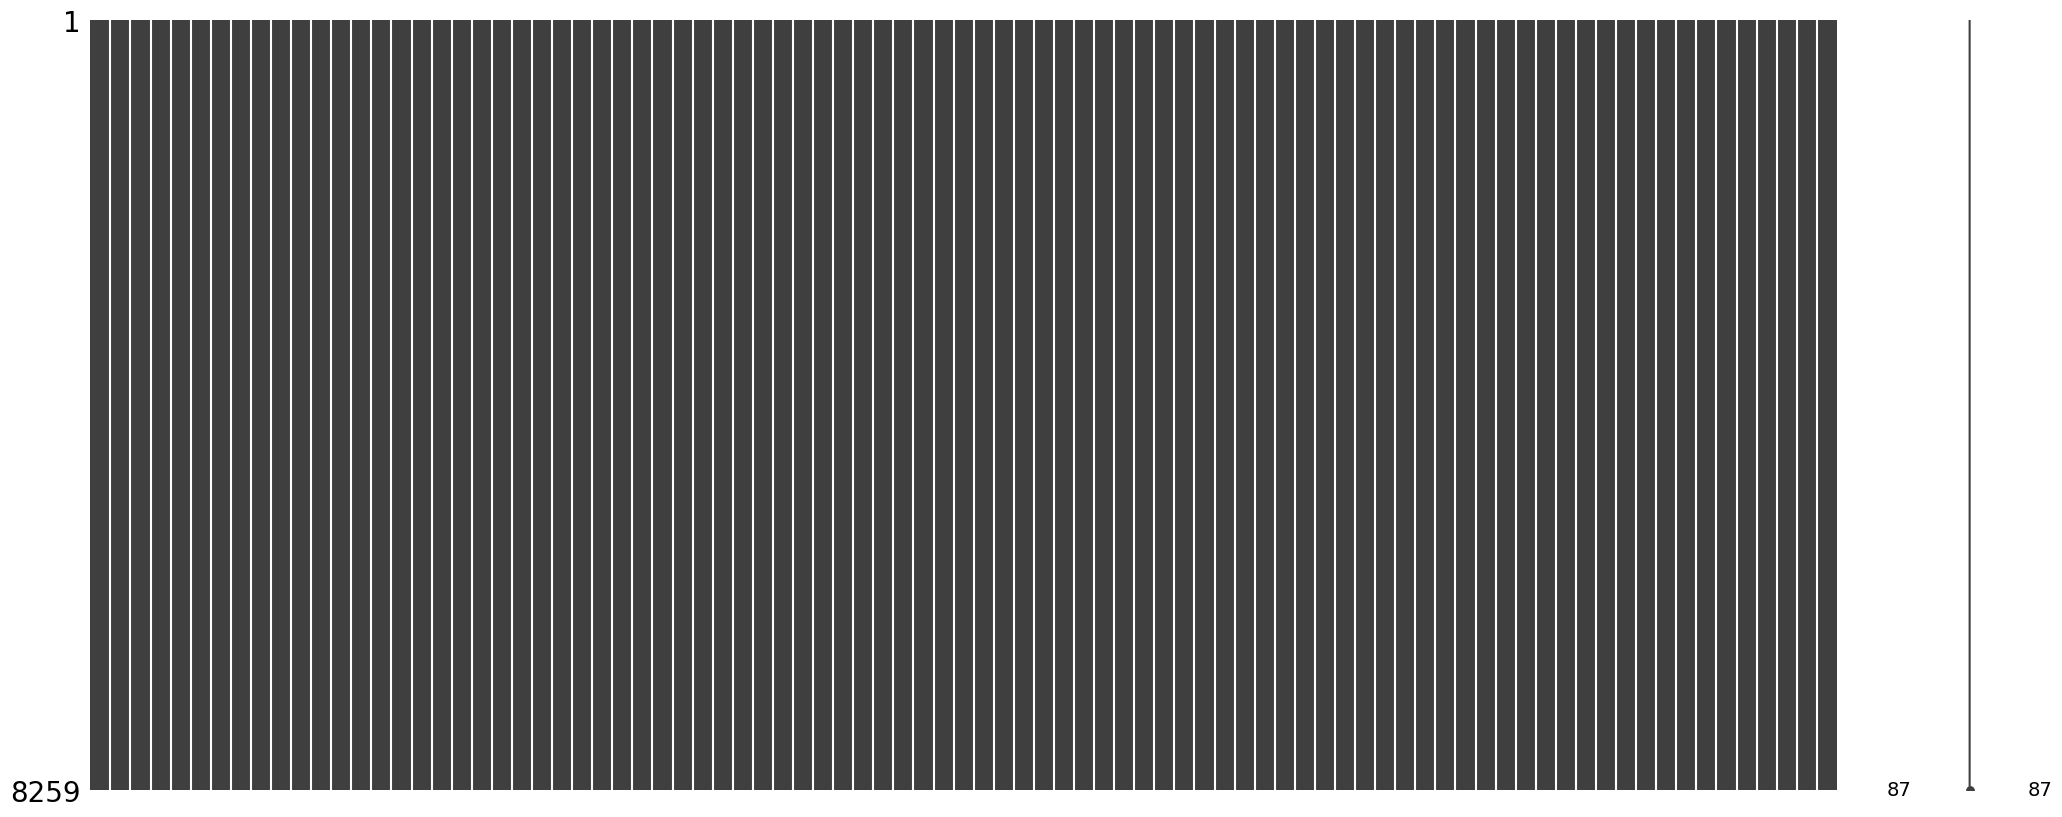

In [21]:
msno.matrix(result)

In [6]:
missing_df = pd.DataFrame({
        'Column': missing_percentage.index,
        'Missing Percentage': missing_percentage.values
    }).sort_values('Missing Percentage', ascending=False)
    

NameError: name 'missing_percentage' is not defined

In [5]:
cols_with_missing = missing_df[missing_df['Missing Percentage'] > 1]['Column'].tolist()

NameError: name 'missing_df' is not defined

In [4]:
df3_train[cols_with_missing]

NameError: name 'cols_with_missing' is not defined

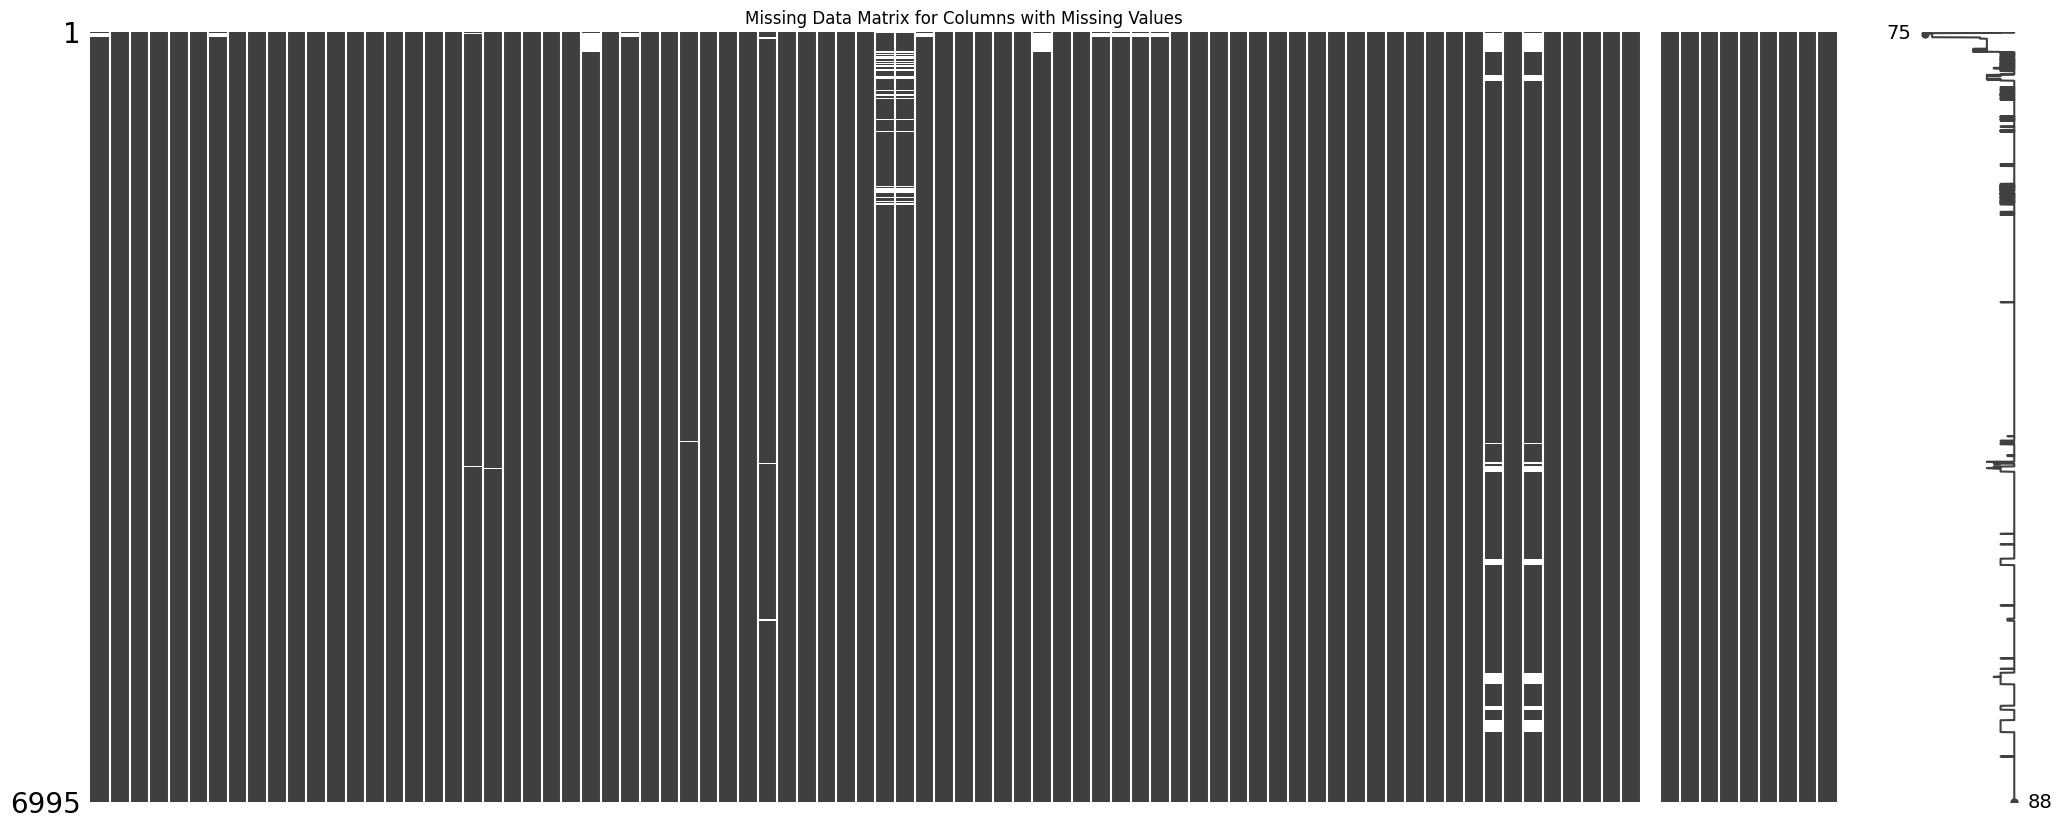

In [52]:
msno.matrix(df3_train)
plt.title("Missing Data Matrix for Columns with Missing Values")
plt.show()


In [ ]:
null_cols = df1_train.columns[df1_train.isnull().sum() > 1]
null_count = {}
for col in null_cols:
    
    null_count[col] = df1_train[col].isnull().sum()
pd.DataFrame(null_count, index=[0])    
